In [1]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget
from matplotlib.colors import Normalize

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames

import scipy.stats as stats

In [3]:
# first set the paths and logger. You can see all kind of outputs in this directory 
# already. Poster used plots from this directory.

data = {}
nas_dir = C.device_paths()[0]
output_dir = f"../outputs/validation/vel_corr/"
Logger().init_logger(None, None, logging_level="WARNING")

In [4]:
# analysis was intially done on all sessions from animal 6 with paradigm 1100
# But the poster focused on S8-15

animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [5]:
session_dirs, _ = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)
session_names = fullfnames2snames(session_dirs)

In [49]:
kinematics = analytics.get_analytics('TrackKinematics', session_names=session_names)
kinematics


frame_id  frame_pc_timestamp  \
paradigm_id animal_id session_id entry_id                                 
6           1100      0          0            14109    1731592882746345   
                                 1            14110    1731592882763007   
                                 2            14111    1731592882779674   
                                 3            14112    1731592882797859   
                                 4            14113    1731592882814538   
...                                             ...                 ...   
                      33         265636      287569    1737986032936566   
                                 265637      287570    1737986032953237   
                                 265638      287571    1737986032969901   
                                 265639      287572    1737986032986570   
                                 265640      287573    1737986033003237   

                                           frame_position  frame_state  \
paradigm_id animal_id session_id entry_id                                
6           1100      0          0                 0.0000         1119   
                                 1                 0.0000         1119   
                                 2                 0.0000         1119   
                                 3                 0.0000         1119   
                                 4                 0.0000         1119   
...                                                   ...          ...   
                      33         265636         -166.7919         1106   
                                 265637         -166.7178         1106   
                                 265638         -166.6485         1106   
                                 265639         -166.5945         1106   
                                 265640         -166.5251         1106   

                                           ballvelocity_first_package  \
paradigm_id animal_id session_id entry_id                               
6           1100      0          0                          902934952   
                                 1                          902934976   
                                 2                          902935039   
                                 3                          902935086   
                                 4                          902935127   
...                                                               ...   
                      33         265636                     221597087   
                                 265637                     221597112   
                                 265638                     221597136   
                                 265639                     221597161   
                                 265640                     221597184   

                                           ballvelocity_last_package  \
paradigm_id animal_id session_id entry_id                              
6           1100      0          0                         902934975   
                                 1                         902935038   
                                 2                         902935085   
                                 3                         902935126   
                                 4                         902935165   
...                                                              ...   
                      33         265636                    221597111   
                                 265637                    221597135   
                                 265638                    221597160   
                                 265639                    221597183   
                                 265640                    221597210   

                                           frame_ephys_timestamp  trial_id  \
paradigm_id animal_id session_id entry_id                                    
6           1100      0          0                           

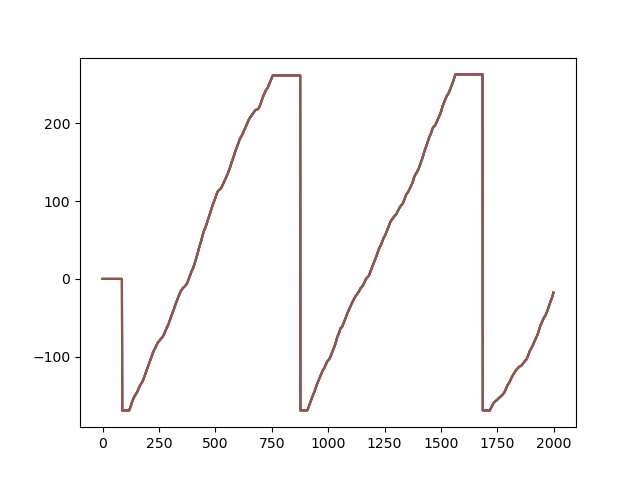

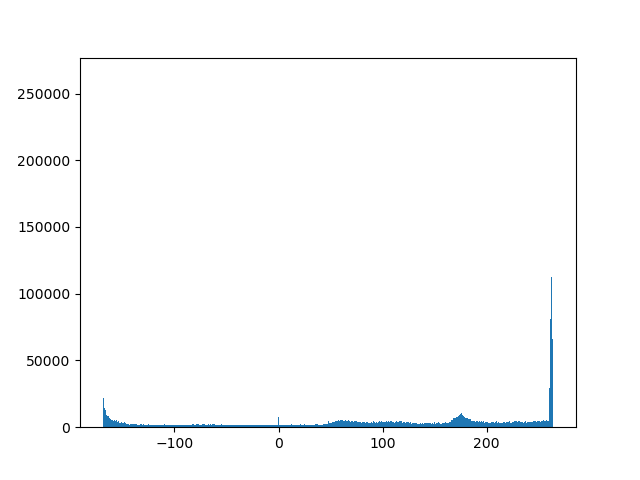

In [81]:
plt.close()
plt.plot(kinematics.frame_position[:2000].reset_index(drop=True))
plt.show()

plt.figure()
plt.hist(kinematics.frame_position.values, bins=1000)
plt.show()


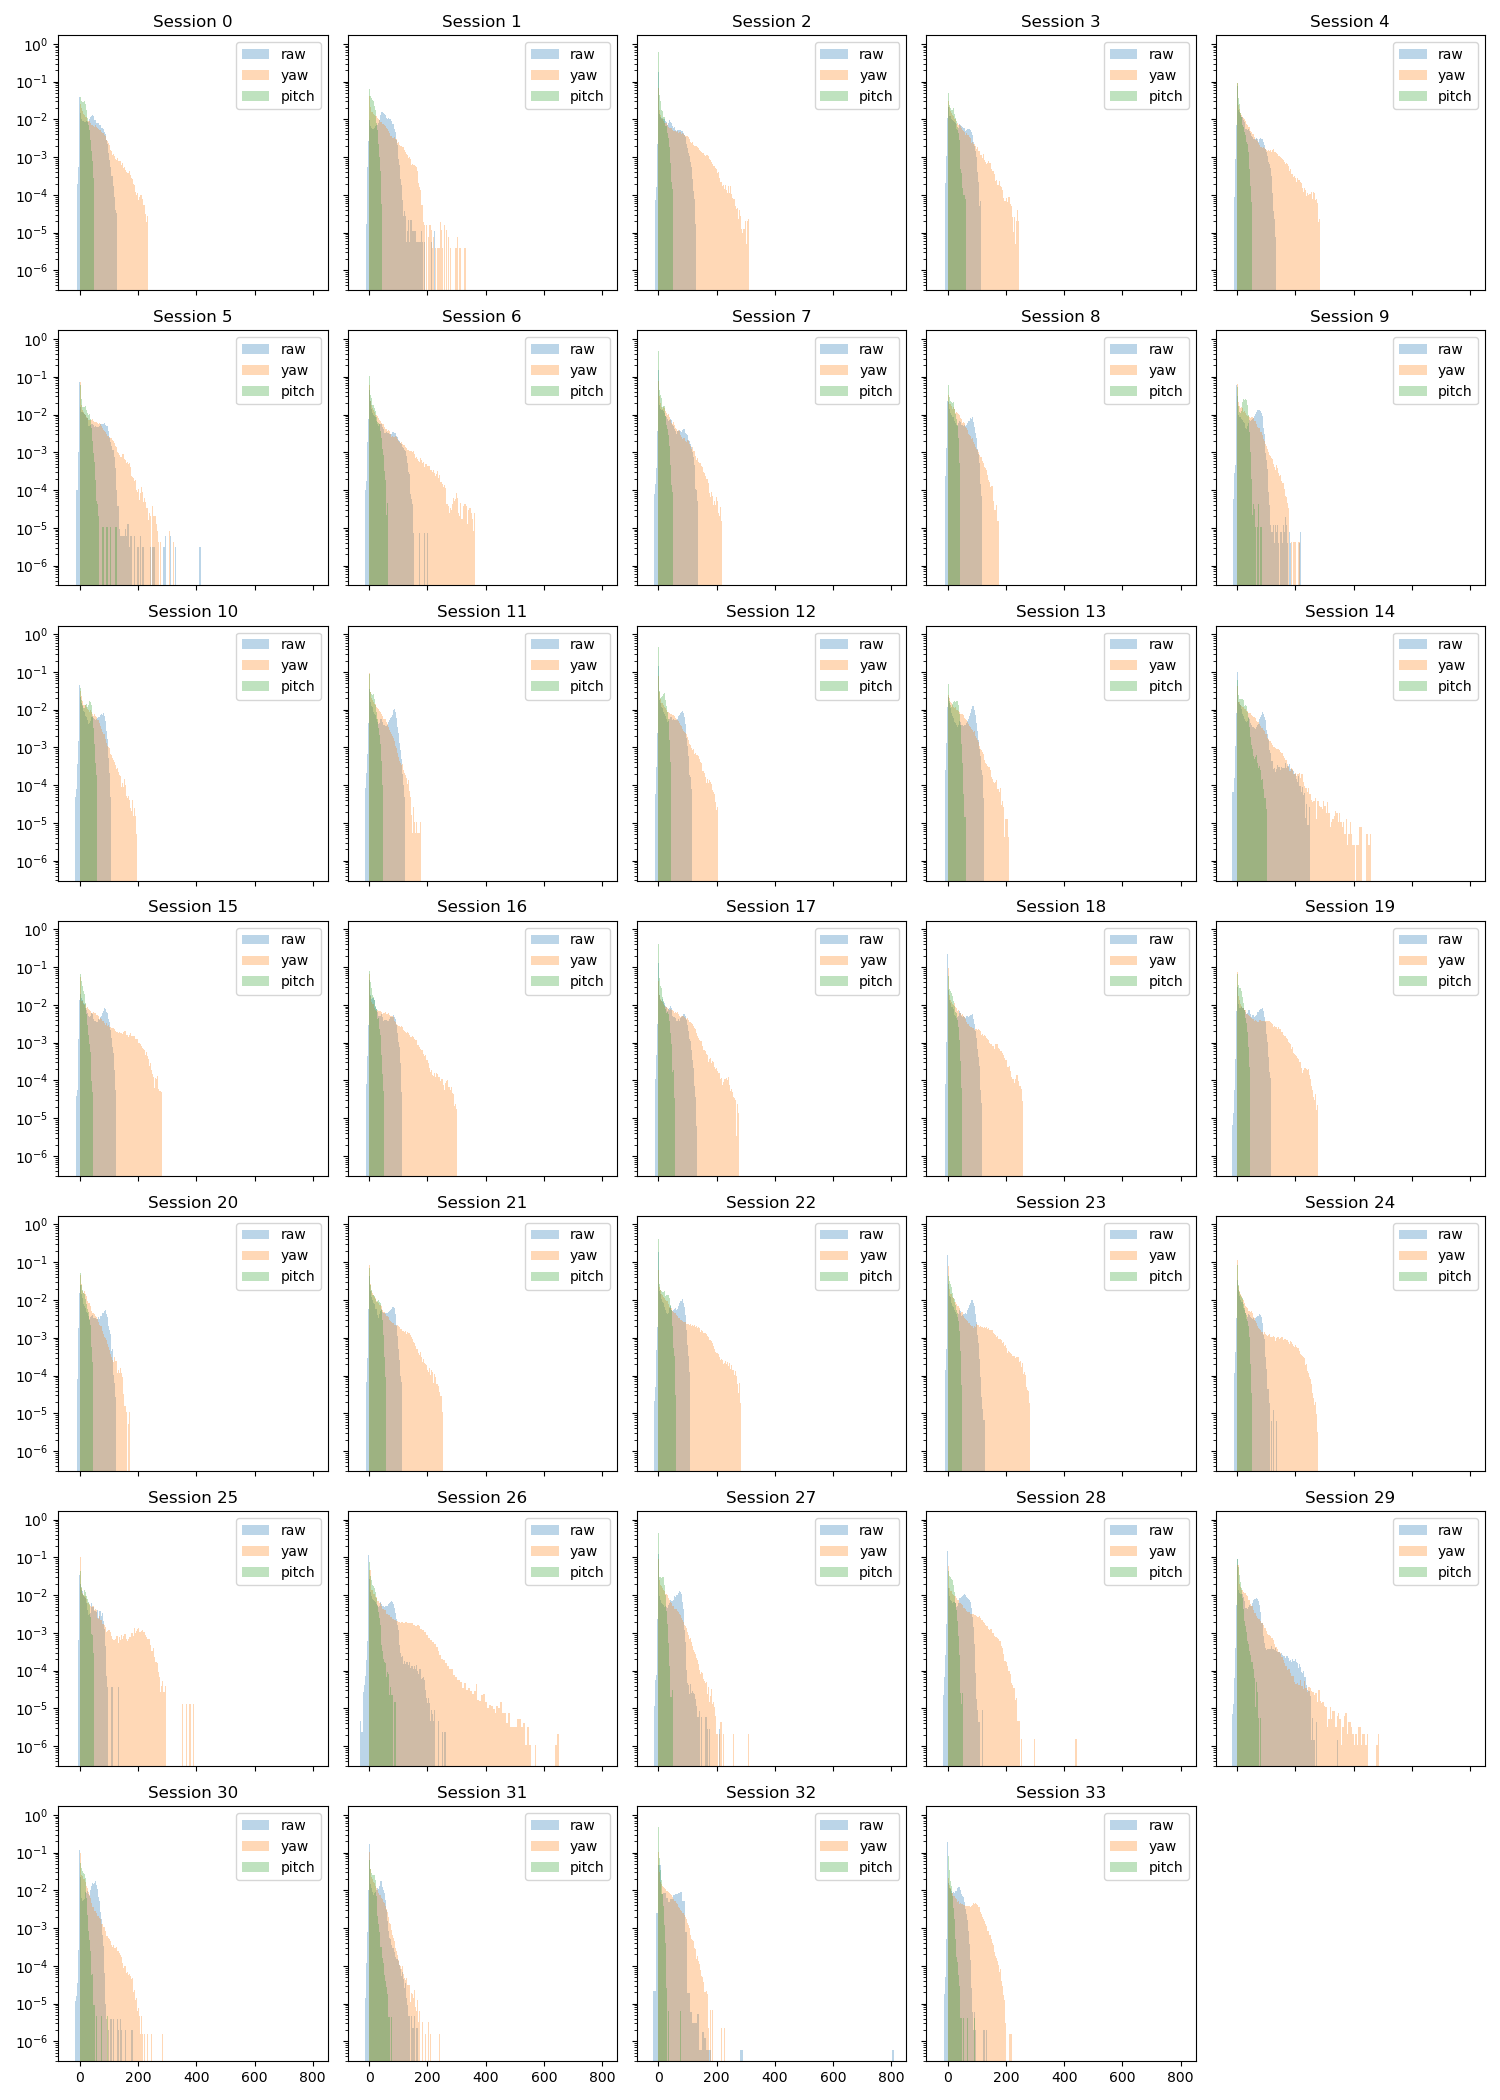

In [ ]:
plt.close('all')

# Get unique session IDs
session_ids = kinematics.index.get_level_values('session_id').unique()
n_sessions = len(session_ids)

# Calculate grid dimensions (5 columns)
n_cols = 5
n_rows = int(np.ceil(n_sessions / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), 
                         squeeze=False, sharex=True, sharey=True)
axes = axes.flatten()

for i, s_id in enumerate(session_ids):
    # if s_id ==5:
    #     continue
    ax = axes[i]
    ax.hist(kinematics['frame_raw'].xs(s_id, level='session_id').values, bins=100, alpha=0.3, label='raw', density=True)
    ax.hist(kinematics['frame_yaw'].abs().xs(s_id, level='session_id').values, bins=100, alpha=0.3, label='yaw', density=True)
    ax.hist(kinematics['frame_pitch'].abs().xs(s_id, level='session_id').values, bins=100, alpha=0.3, label='pitch', density=True)
    
    # ax.set_xlim(-5, 250)
    plt.yscale('log')
    ax.legend()
    ax.set_title("Session " + str(s_id))

plt.tight_layout()
plt.show()


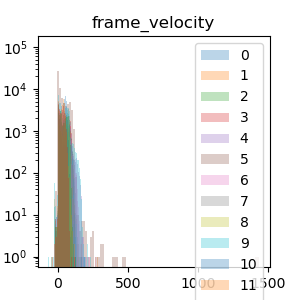

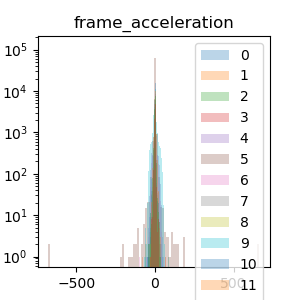

In [50]:
plt.close('all')
cols = ['frame_velocity', 'frame_acceleration', ]#'frame_raw', 'frame_yaw', 'frame_pitch', 'frame_RawYawPitch_abs_velocity_sum']
for col in cols:
    plt.figure(figsize=(3,3))
    # mask = kinematics[col] >250
    # plt.scatter(kinematics[col][mask].values, kinematics.index.get_level_values('session_id')[mask])
    for s_id in kinematics.index.get_level_values('session_id').unique():
        # if s_id <8:
        #     continue
        plt.hist(kinematics[col].xs(s_id, level='session_id').values, bins=100, alpha=0.3, label=s_id)
    # plt.hist(kinematics[col].values, bins=100)
    plt.yscale('log')
    plt.legend()
    plt.title(col)
    plt.show()
    # break

In [58]:
kinematics[['frame_position']].max()

frame_position    263.9999
dtype: float64

/tmp/ipykernel_20565/140509612.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


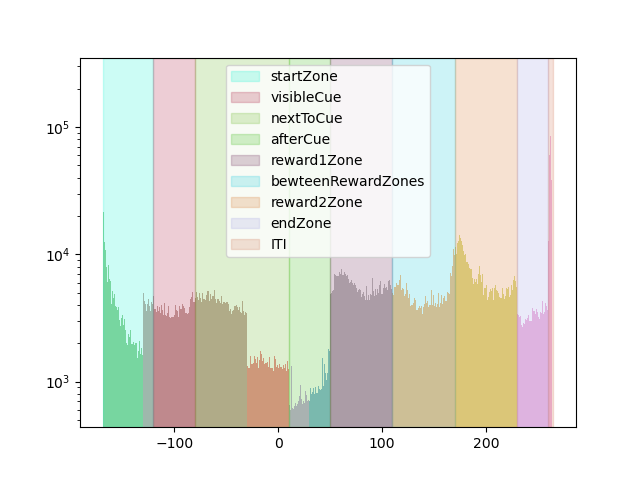

In [82]:
plt.close('all')
dat = kinematics[['track_zone', 'frame_position']]
# sample
# dat = np.random.choice(dat.values, size=1_000_000, replace=False)
for zone in np.unique(dat['track_zone']):
    plt.hist(dat['frame_position'][dat['track_zone']==zone], bins=100, alpha=0.5, )#label=str(zone))
plt.legend()
plt.yscale('log')
# plt.scatter(dat['frame_position'], dat['frame_id'], 
#             c=dat['track_zone'].cat.codes, label=dat['track_zone'], 
#             cmap='tab20')
# plt.colorbar(label='track_zone')
# framew_beh.columns.tolist()

# lines = {
#         'cueZone_visible': -120,
#         'cueZone_entry': -80,
#         'cueZone_exit': 10,
#         'enter_reward1Zone': 50,
#         'enter_reward2Zone': 170,}

zones = {
    'startZone': (-169,-120),
    'visibleCue': (-120,-80),
    'nextToCue': (-80,10),
    'afterCue': (10, 50),
    'reward1Zone': (50,110),
    'bewteenRewardZones': (110,170),
    'reward2Zone': (170,230),
    'endZone': (230,260),
    'ITI': (260,265),
}

# use span
for z in zones:
    color = np.random.rand(3,)
    plt.axvspan(*zones[z], color=color, alpha=0.2, label=z)

plt.legend()
plt.show()


Session 0: 126 trials


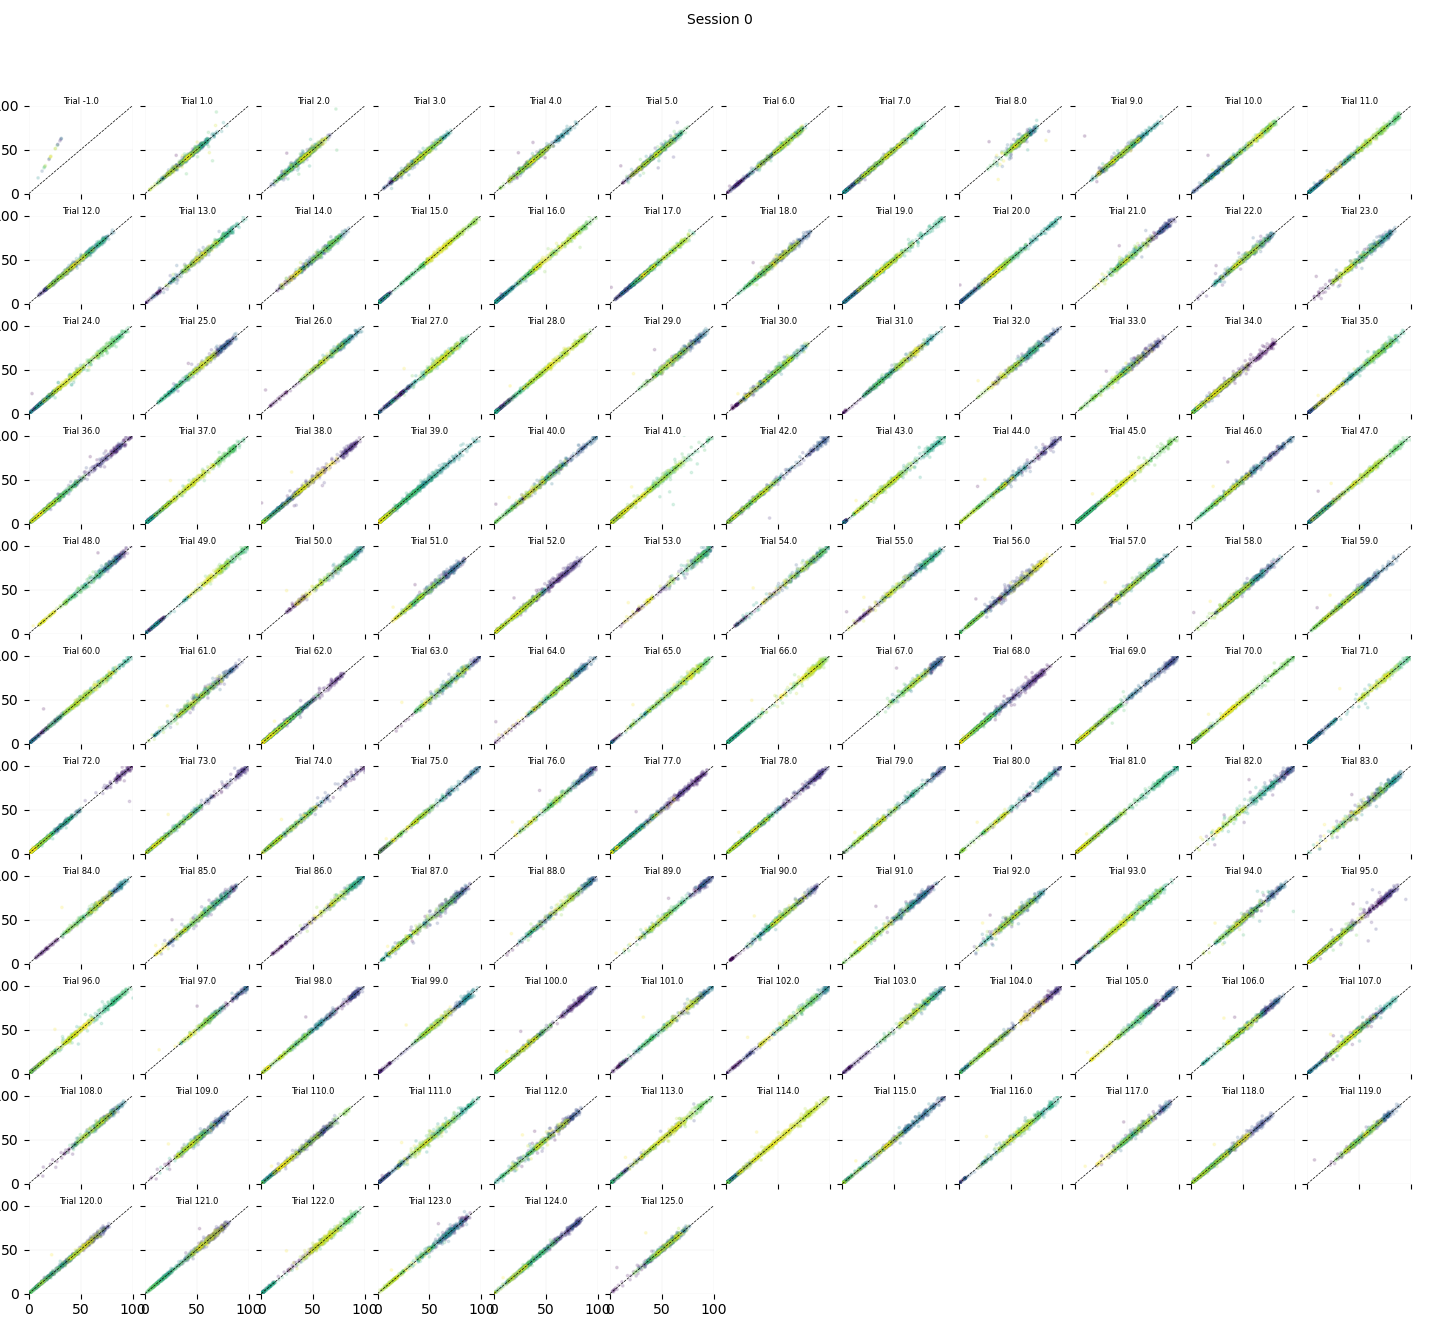

In [10]:
plt.close('all')

# Get unique session IDs
session_ids_unique = kinematics.index.get_level_values(2).unique()

for session_id in session_ids_unique:
    # Select one session
    kin = kinematics.loc[(slice(None), slice(None), session_id),]
    
    # Get unique trial IDs
    trial_ids = kin.trial_id.unique()
    n_trials = len(trial_ids)
    print(f"Session {session_id}: {n_trials} trials")
    
    # Calculate grid dimensions
    n_cols = min(12, n_trials)  # Max 12 columns
    n_rows = int(np.ceil(n_trials / n_cols))
    
    # Create figure with shared axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.2), 
                             sharex=True, sharey=True, squeeze=False)
    axes = axes.flatten()
    
    for i, trial_id in enumerate(trial_ids):
        ax = axes[i]
        
        # Filter data for this trial
        trial_kin = kin[kin.trial_id == trial_id]
        unity_vel = trial_kin.frame_velocity.clip(-20, 2000)
        ball_vel = trial_kin.frame_raw
        
        # Remove disabled movement frames
        disabled_movement_mask = unity_vel < 0.001
        unity_vel = unity_vel[~disabled_movement_mask]
        ball_vel = ball_vel[~disabled_movement_mask]
        
        if len(unity_vel) > 0:
            color = trial_kin.frame_id[~disabled_movement_mask]
            ax.scatter(unity_vel, ball_vel, c=color, alpha=0.15, s=3)
            ax.plot([0, 100], [0, 100], 'k--', linewidth=0.5)
        
        ax.set_title(f'Trial {trial_id}', fontsize=6, pad=1)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        
        # Add grid, remove spines
        ax.grid(True, alpha=0.3, linewidth=0.3)
        for spine in ax.spines.values():
            spine.set_visible(False)
        # ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)jachudi
        
        
        
    
    # Hide unused subplots
    for i in range(n_trials, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Session {session_id}', fontsize=10, y=0.99)
    plt.subplots_adjust(wspace=0.12, hspace=0.25, left=0.02, right=0.98, top=0.92, bottom=0.02)
    # save them in output dir
    plt.savefig(f"{output_dir}/vel_correlation_session_{session_id:02d}.png", dpi=300)
    if session_id < 3:
        plt.show()
    else:
        plt.close(fig)
    break

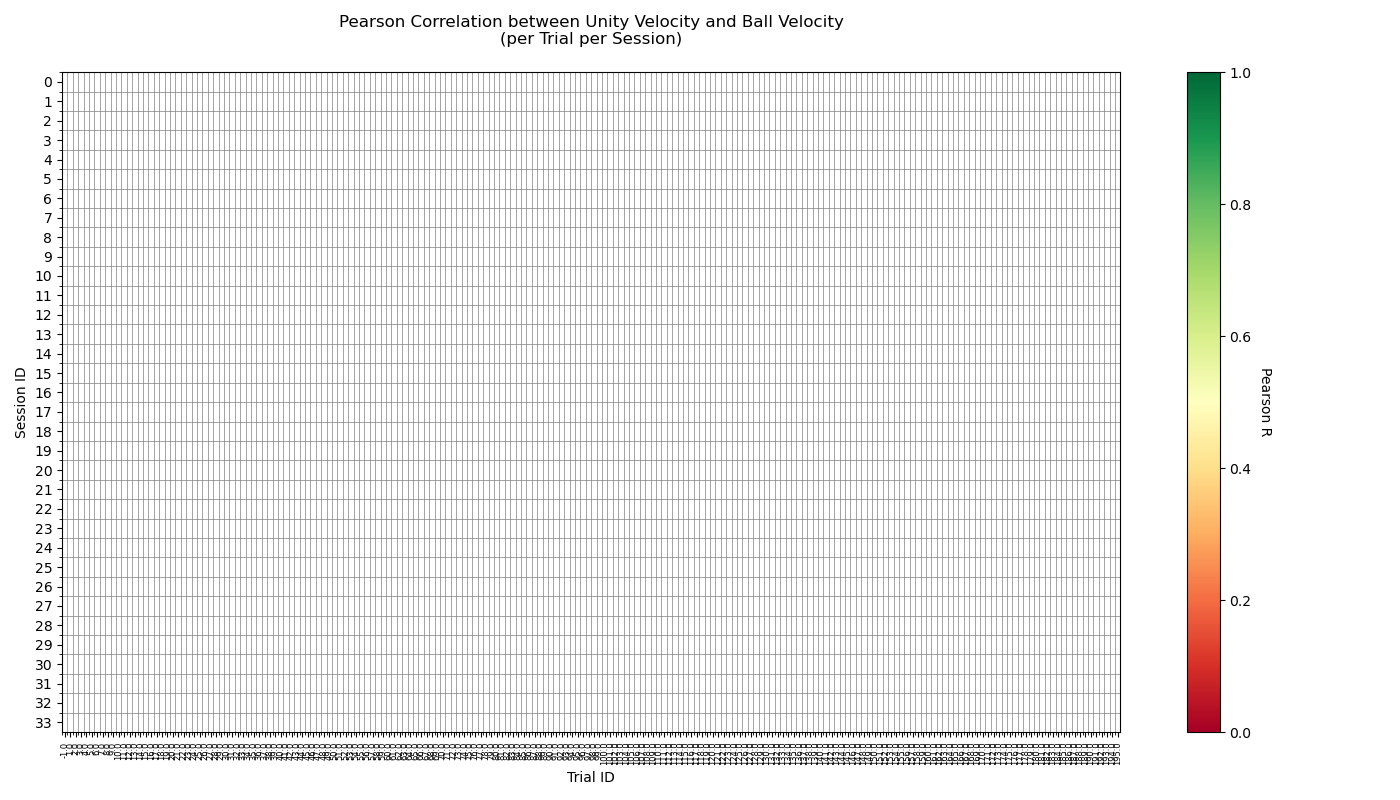


Pearson R Summary Statistics:
Mean R: nan
Median R: nan
Min R: nan
Max R: nan
Std R: nan


In [8]:
# Calculate Pearson R for each session-trial combination
from scipy.stats import pearsonr

# Get unique session IDs
session_ids_unique = kinematics.index.get_level_values(2).unique()

# Dictionary to store correlations
correlations = []

for session_id in session_ids_unique:
    # Select one session
    kin = kinematics.loc[(slice(None), slice(None), session_id),]
    
    # Get unique trial IDs
    trial_ids = kin.trial_id.unique()
    
    for trial_id in trial_ids:
        # Filter data for this trial
        trial_kin = kin[kin.trial_id == trial_id]
        unity_vel = trial_kin.frame_velocity.clip(-20, 2000)
        ball_vel = trial_kin.frame_raw
        
        # Remove disabled movement frames
        disabled_movement_mask = unity_vel < 0.001
        unity_vel = unity_vel[~disabled_movement_mask]
        ball_vel = ball_vel[~disabled_movement_mask]
        
        # Calculate Pearson R if we have enough data
        if len(unity_vel) > 1:
            r, p_value = pearsonr(unity_vel, ball_vel / 10.8)
            correlations.append({
                'session_id': session_id,
                'trial_id': trial_id,
                'pearson_r': r,
                'p_value': p_value
            })

# Convert to DataFrame
corr_df = pd.DataFrame(correlations)

# Pivot to create a matrix: sessions as rows, trials as columns
corr_matrix = corr_df.pivot(index='session_id', columns='trial_id', values='pearson_r')

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(corr_matrix.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, fontsize=6)
ax.set_yticklabels(corr_matrix.index)

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson R', rotation=270, labelpad=15)

# Add title and labels
ax.set_xlabel('Trial ID')
ax.set_ylabel('Session ID')
ax.set_title('Pearson Correlation between Unity Velocity and Ball Velocity\n(per Trial per Session)', 
             pad=20)

# Add grid
ax.set_xticks(np.arange(len(corr_matrix.columns))-.5, minor=True)
ax.set_yticks(np.arange(len(corr_matrix.index))-.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{output_dir}/pearson_r_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nPearson R Summary Statistics:")
print(f"Mean R: {corr_df['pearson_r'].mean():.3f}")
print(f"Median R: {corr_df['pearson_r'].median():.3f}")
print(f"Min R: {corr_df['pearson_r'].min():.3f}")
print(f"Max R: {corr_df['pearson_r'].max():.3f}")
print(f"Std R: {corr_df['pearson_r'].std():.3f}")